# Analysis of mirror codes
This is a high-level wrapper of the mirror code and benchmarking functionalities of this repository, enabling benchmarking of a chosen mirror code.

In [5]:
from mirror import MirrorCode
from benchmark import StabilizerCode, make_noise_model
import numpy as np
import matplotlib.pyplot as plt
import stim
import sinter
from tesseract_decoder import make_tesseract_sinter_decoders_dict, TesseractSinterDecoder
import tesseract_decoder

As an example, let us benchmark the `[[n, k, d, w]] = [[36, 6, 6, 6]]` code.

In [6]:
# [[36, 6, 6, 6]] code
code = MirrorCode(
        group = [2, 2, 3, 3],
        z0 = [[0, 0, 0, 0],
       [0, 1, 0, 1],
       [1, 0, 0, 2]],
        x0 = [[0, 0, 0, 0],
       [0, 1, 1, 0],
       [1, 1, 2, 0]]
    )

CODE_NAME = "[[36, 6, 6]]"
NOISE_MODEL_NAME = "SI1000"

In [8]:
print("Finding stabilizers...")
stabilizers = code.get_stim_tableau()
print("Done.")

benchmarker = StabilizerCode(stabilizers, verbose=False, name=CODE_NAME)

T = 6 # min error rate is 10^-T
NUM_PROBS = 1

# Define the main parameters of the benchmarking
ROUND_CHOICES = [3, 6, 9]
PS = np.logspace(-T, -2, NUM_PROBS)
NUM_SHOTS = 1_000

print("Making syndrome extraction circuits...")
SECS = [code.bare_ancilla_sec(noise=make_noise_model(PS[i], NOISE_MODEL_NAME),
                              num_rounds=nrd
                              )
                            for nrd in ROUND_CHOICES
                            for i in range(len(PS))
        ]
print("Done")

Finding stabilizers...
Done.
Making syndrome extraction circuits...
Done


Starting 8 workers...
3 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                     
        3 tesseract <1m        668           0 p=1e-06,decoder=tesseract,rounds=3
        3 tesseract   ?       1000           0 p=1e-06,decoder=tesseract,rounds=6
        2 tesseract   ?       1000           0 p=1e-06,decoder=tesseract,rounds=9
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                     
        8 tesseract <1m          2           0 p=1e-06,decoder=tesseract,rounds=6
0 tasks left:



/Users/jzlu/Dropbox/mirrorcodes/benchmark.py:323: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  print("Done")


     shots,    errors,  discards, seconds,decoder,strong_id,json_metadata,custom_counts
      1000,         0,         0,   0.015,tesseract,6574fb9ae0fc54363b656abc6f31a457496715f9289e3dc557139f33b0eb55b7,"{""decoder"":""tesseract"",""p"":1e-06,""rounds"":3}",
      1000,         0,         0,   0.011,tesseract,ea07e6ff340b6485af8c2d550c20b2a2a8e6ca74b17bc9ec680044ab904795d1,"{""decoder"":""tesseract"",""p"":1e-06,""rounds"":9}",
      1000,         0,         0,   0.008,tesseract,df29e5579441da8053e810cc9e95628f029b55cfd6949a91dd3c87e44107f941,"{""decoder"":""tesseract"",""p"":1e-06,""rounds"":6}",


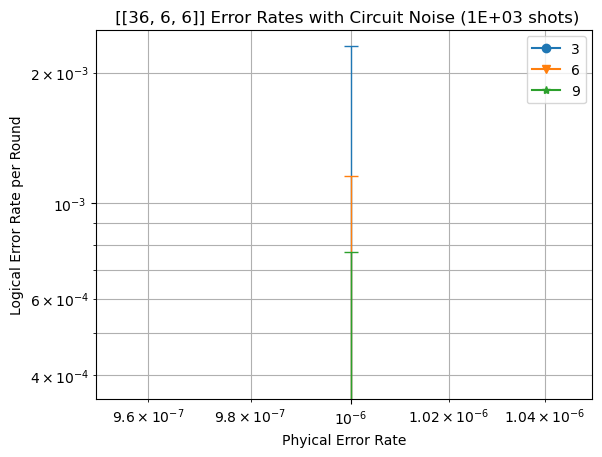

In [9]:
sinter_stats = benchmarker.sinter_benchmark(ps=PS,
                               secs=SECS,
                               rounds_choices=ROUND_CHOICES,
                               num_shots=NUM_SHOTS,
                               plot=True,
                               verbose=True
                               )